# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|  Group 35  |           Student number          |
|------------|----------------------|
| Belouaer, Zeyd  |        6160662       |
| Dos Santos Roldão, Vasco  |        6127916       |
| Jacobs, Mats  |        6255698       |
| Kopmels, Kylian  |        6164846       |

</div>

#### Imports

In [1]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors

#### Loading the data

In [2]:
features = np.genfromtxt("../data/features.txt", delimiter=", ")
targets = np.genfromtxt("../data/targets.txt", delimiter=", ")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=", ")

# split the data up into a training set, a validation set and a testing set
N = len(features)
train_end_idx = int(0.70 * N) # first 70%
val_end_idx = train_end_idx + int(0.15 * N) # 71-85%

train_features = features[:train_end_idx]           # use the first 70% for training
val_features = features[train_end_idx:val_end_idx]  # use the next 15% for validation
test_features = features[val_end_idx:]              # use the other 15% for testing

train_targets = targets[:train_end_idx].astype(int)             # use the first 70% for training
val_targets = targets[train_end_idx:val_end_idx].astype(int)    # use the next 15% for validation
test_targets = targets[val_end_idx:].astype(int)                # use the other 15% for testing

## 1 Questions
### 1.2 Architecture
#### Question 1:

In [ ]:
# Put your code for Question 1 here
learnrate = 0.01

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def loss(y_true, y_pred):
    return np.sum(-y_true * np.log(y_pred) - (1 - y_true) * np.log(1-y_pred))

def loss_deriv(y_true, out, z, input):
    return ((out - y_true) * input).sum(axis=0)[:, np.newaxis]

def bias_deriv(y_true, out, z):
    return np.sum(-2 * (y_true - out) * sigmoid_derivative(z))

input_and =     np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
output_and =    np.array([[0], [0], [0], [1]])
weights_and =   np.random.rand(2, 1)
bias_and =      np.random.rand(1, 1)
and_losses =    np.zeros(10000)

input_or =      np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
output_or =     np.array([[0], [1], [1], [1]])
weights_or =    np.random.rand(2, 1)
bias_or =       np.random.rand(1, 1)
or_losses =     np.zeros(10000)

input_xor =     np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
output_xor =    np.array([[0], [1], [1], [0]])
weights_xor =   np.random.rand(2, 1)
bias_xor =      np.random.rand(1, 1)
xor_losses =    np.zeros(10000)

for epoch in range(10000):
    zi_and = np.dot(input_and, weights_and) + bias_and[0][0]
    out_and = sigmoid(zi_and)
    and_losses[epoch] = loss(output_and, out_and)

    zi_or = np.dot(input_or, weights_or) + bias_or[0][0]
    out_or = sigmoid(zi_or)
    or_losses[epoch] = loss(output_or, out_or)

    zi_xor = np.dot(input_xor, weights_xor) + bias_xor[0][0]
    out_xor = sigmoid(zi_xor)
    xor_losses[epoch] = loss(output_xor, out_xor)


    weights_and -= learnrate*loss_deriv(output_and, out_and, zi_and, input_and)
    bias_and -= learnrate*bias_deriv(output_and, out_and, zi_and)
    
    weights_or -= learnrate*loss_deriv(output_or, out_or, zi_or, input_or)
    bias_or -= learnrate*bias_deriv(output_or, out_or, zi_or)
    
    weights_xor -= learnrate*loss_deriv(output_xor, out_xor, zi_xor, input_xor)
    bias_xor -= learnrate*bias_deriv(output_xor, out_xor, zi_xor)

x_axis = np.linspace(0, 10000, 10000)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.plot(x_axis, and_losses, label = "and")
plt.plot(x_axis, or_losses, label = "or")
plt.plot(x_axis, xor_losses, label = "xor")
plt.legend()
plt.show()


<div style="background-color:#f1be3e">

As is visible by the plot, the loss goes down for all 3 functions. The xor function stops very early at a bit less than 3, which is expected as our single perceptron cannot create a linear seperator to accurately predict the output of the xor function. For "and" and "or", we can make a much more accurate seperator, but even here the loss settles down above 0 since it is still not possible to have a classifier that perfectly seperates the outputs based on the input. Here is what the AND and OR linear seperators look like:

AND: 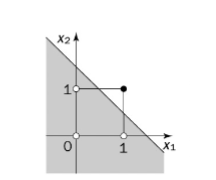
OR: 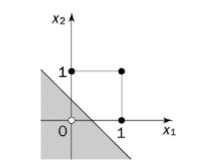

</div>

#### Question 2

<div style="background-color:#f1be3e">

There are 10 features, so we use 10 input neurons.

</div>

#### Question 3

<div style="background-color:#f1be3e">

We have 7 output labels, so we use 7 output neurons.

</div>

#### Question 4

<div style="background-color:#f1be3e">

We will start by using 2 hidden layers of 20 nodes each. This doesn't seem unreasonable large nor does it seem unreasonably small.

</div>

#### Question 5

<div style="background-color:#f1be3e">

We have multiple mutually exclusive labels so we should use softmax for the output layer. We use ReLU for the hidden layers as this helps prevent vanishing gradients.

</div>

#### Question 6

<div style="background-color:#f1be3e">

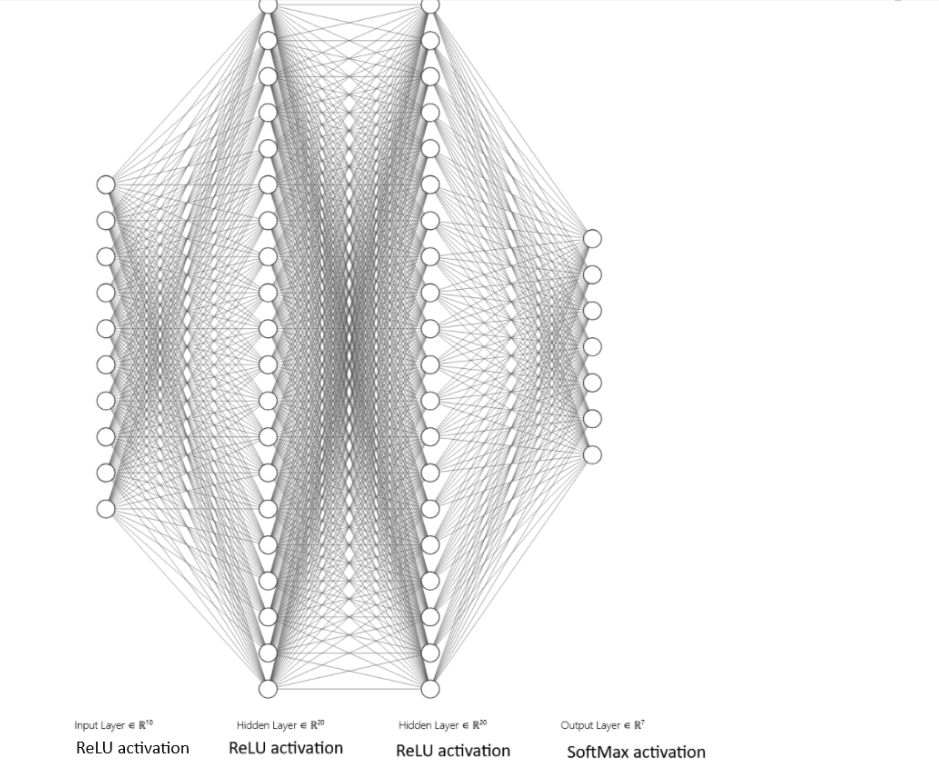

</div>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [ ]:
class Linear:
    def __init__(self, in_features, out_features):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
        """

        self.weight = np.random.randn(out_features, in_features) * np.sqrt(2 / in_features)
        self.bias = np.zeros((out_features, 1))

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.
        

        Returns:
            y: output of a linear layer.
        """
        self.cache = x
        temp = self.weight @ x
        return temp + self.bias
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  
        
        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = dupstream @ self.cache.T
        self.bias_grad = np.sum(dupstream, axis=1, keepdims=True)
        return self.weight.T @ dupstream
    
    def outputgrad(self, expected):
        return self.weight @ self.cache + self.bias - expected

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [ ]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        self.cache = x
        return np.maximum(0, x)
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        return dupstream * (self.cache > 0) * 1.0 
        


**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [ ]:
class Network:
    def __init__(self, layers):
        self.layers = layers
        self.activations = [Activation() for _ in range (len(layers)-1)]
    
    def forward(self, x):
        """ Perform a forward pass over the entire network.
        
        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        
        for i in range(len(self.layers)-1):
            layer = self.layers[i]
            x = self.activations[i].forward(layer.forward(x))

        x = self.layers[-1].forward(x)
        x_stable = x - np.max(x, axis=0, keepdims=True)
        return np.exp(x_stable) / np.sum(np.exp(x_stable), axis = 0, keepdims = True) 
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        dupstream = self.layers[-1].backward(dupstream)
        for i in range(len(self.layers)-2, -1, -1):
            dupstream = self.layers[i].backward(self.activations[i].backward(dupstream))
        return dupstream

    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        for layer in self.layers:
            layer.weight    -= layer.weight_grad * lr
            layer.bias      -= layer.bias_grad * lr

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [ ]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    return (-np.sum(y_true * np.log(y_pred + 1e-12)) / y_true.shape[1],
            ((y_pred + 1e-12) - y_true) / y_true.shape[1])
    

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

<function matplotlib.pyplot.show(close=None, block=None)>

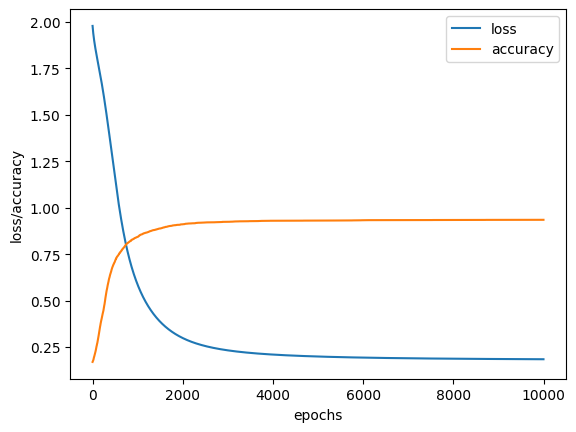

In [ ]:
def train(net, inputs, labels, criterion, lr):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    losses = np.zeros(10000)
    accuracy = np.zeros(10000)
    
    for epoch in range(10000):
        predictions = net.forward(inputs)
        encodedlabels = np.zeros((7, len(labels)))
        encodedlabels[labels-1, np.arange(len(labels))] = 1

        loss, grad = criterion(encodedlabels, predictions)
        finalgrad = net.backward(grad)
        pred = np.argmax(predictions, axis=0) + 1
        losses[epoch] = loss
        accuracy[epoch] = np.sum(pred == labels) / pred.size
        net.optimizer_step(lr)
    return losses, accuracy


network = Network([Linear(10, 20), Linear(20, 20), Linear(20, 7)])
losses, accuracies = train(network, train_features.T, train_targets, Loss, 0.01)

plt.plot(losses, label = "loss")
plt.plot(accuracies, label="accuracy")
plt.ylabel("loss/accuracy")
plt.xlabel("epochs")
plt.legend()
plt.show()

#### Question 7

<div style="background-color:#f1be3e">

We use a 70, 15, 15 split for training, validation and testing respectively as recommended by the lecture slides.

</div>

#### Question 8

In [ ]:
def calculate_success_rate(predictions, targets):
    return np.sum(predictions == targets) / predictions.size

<div style="background-color:#f1be3e">

This is a very simple way to find the amount of right predictions and normalize it from 0 to 1 so we can easily compare models.
</div>

#### Question 9

<div style="background-color:#f1be3e">

We used 10000 epochs, as this is high enough to reach convergance and is also reasonable for computation.

</div>

#### Question 10

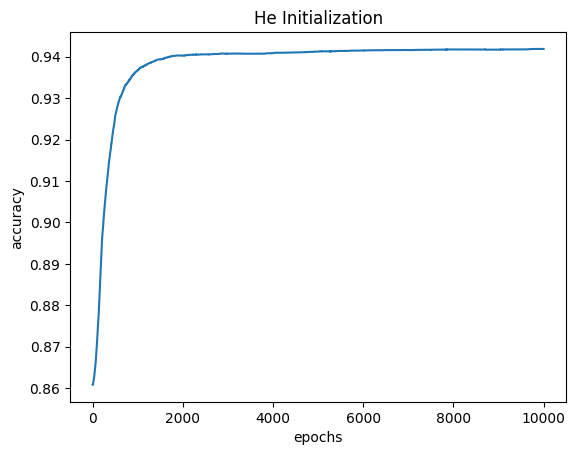

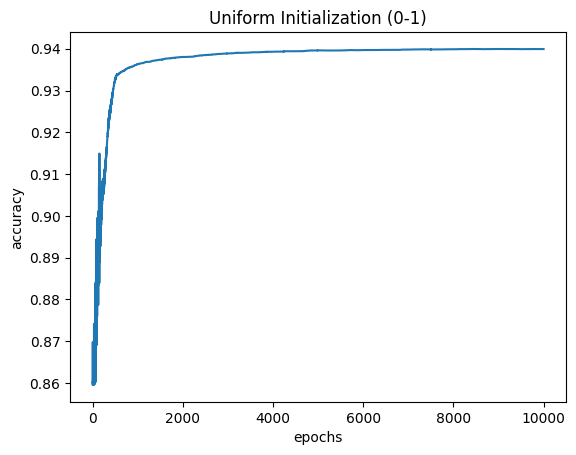

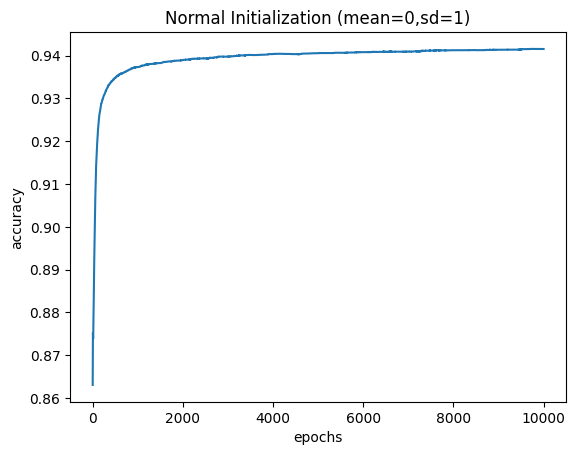

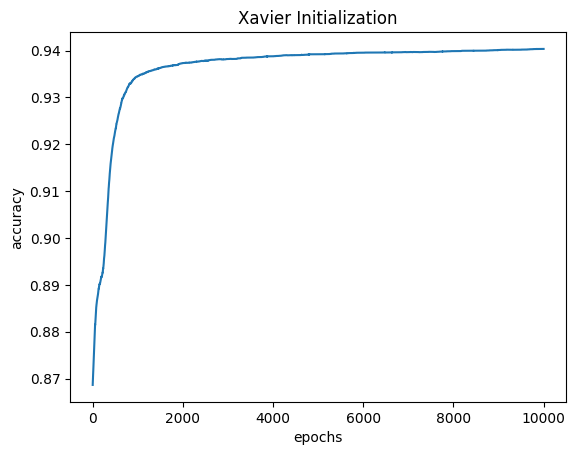

In [ ]:
network_he =        Network([Linear(10, 20), Linear(20, 20), Linear(20, 7)])
network_uniform =   Network([Linear(10, 20), Linear(20, 20), Linear(20, 7)])
network_normal =    Network([Linear(10, 20), Linear(20, 20), Linear(20, 7)])
network_xavier =    Network([Linear(10, 20), Linear(20, 20), Linear(20, 7)])

for layer in network_uniform.layers:
    layer.weight = np.random.rand(layer.weight.shape[0], layer.weight.shape[1])

for layer in network_normal.layers:
    layer.weight = np.random.randn(layer.weight.shape[0], layer.weight.shape[1])

for layer in network_xavier.layers:
    layer.weight = (
        np.random.randn(layer.weight.shape[0], layer.weight.shape[1])
        / np.sqrt(layer.weight.shape[1])
    )


networks = [network_he, network_uniform, network_normal, network_xavier]

accuracy_store = np.zeros((10000, 4))
for i, network in enumerate(networks):
    avgacc = np.zeros(10000)
    for i in range(10):
        loss, acc = train(network, train_features.T, train_targets, Loss, 0.01)
        avg_acc += (acc / 10.0)
    accuracy_store[:, i] = avg_acc

titles = [
    "He Initialization",
    "Uniform Initialization (0-1)",
    "Normal Initialization (mean=0, sd=1)",
    "Xavier Initialization"
]

for i, title in enumerate(titles):
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.plot(accuracy_store[:, i])
    plt.show()

<div style="background-color:#f1be3e">

We see that normal and He initialization are very smooth, while Xavier and Uniform are quite noisy. This is likely because for uniform, our mean is 0.5 instead of 0 and no negative weights, so our model is quite wrong at the start. For Xavier, our variance is the lowest of all the initializations, so we see that the climb is a bit slower than what we like to see.

</div>

### 1.4 Optimization

#### Question 11

In [4]:
def run_network(network, dataset):
    preds = network.forward(dataset.T)
    # targets.txt contains class indexes ranging from 1 to 7
    # but np.argmax returns indexes ranging from 0 to 6
    # so add 1 to align with targets.txt
    return np.argmax(preds.T, axis=1) + 1


neuron_amounts = [10, 15, 20, 25, 30]

def optimize(neuron_amounts):
    # how many times do you train each model?
    # made for easy debugging, just set to 1 and youre 10x faster
    # compared to if you set it to 10 which the assignment wants
    iterations = 10
    
    performances = np.zeros(shape=(len(neuron_amounts), ))
    for i, neuron_amount in enumerate(neuron_amounts):
        print("\r", f"Training the models with {neuron_amount} neurons", end="")

        results = np.zeros(shape=(iterations, ))
        for j in range(iterations):
            network = Network(
                [Linear(10, neuron_amount),
                 Linear(neuron_amount, neuron_amount),
                 Linear(neuron_amount, 7)
                ]
            )
            train(network, train_features.T, train_targets, Loss, 0.01)
            predictions = run_network(network, val_features)
            accuracy = calculate_success_rate(predictions, val_targets)
            results[j] = 100 * accuracy # multiply by 100 to get a nice percentage

            print(
                "\r", 
                f"Fishished run {j+1}/{iterations} for the model with {neuron_amount} neurons ({100*(iterations*i+(j+1))/(len(neuron_amounts)*iterations):.2f}% complete)", 
                end="", 
            )
        print("")
        
        performances[i] = np.mean(results)
    return performances
# it takes about 45 minutes, so be prepared
# hardcoded result for convenience
# if you want to run it, turn
# "None or np.array([...])" into
# "None #or np.array([...])"
performances = None or np.array([92.11375212, 93.27674024, 93.42105263, 93.39558574, 93.45500849])
performances = performances if performances is not None else optimize(neuron_amounts)

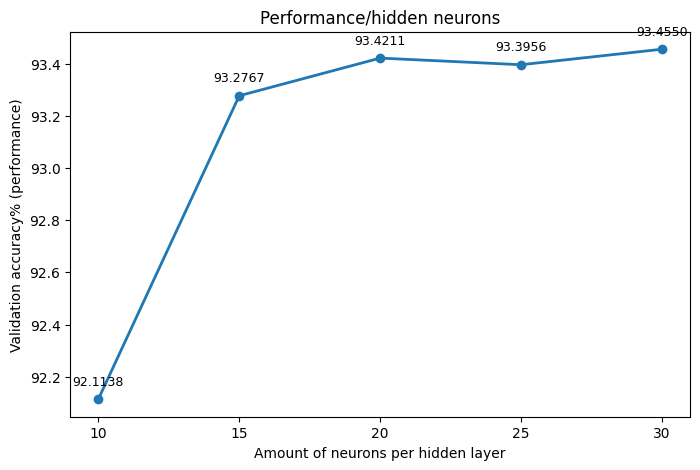

In [5]:
# plot the data
plt.figure(figsize=(8, 5))
plt.plot(neuron_amounts, performances, marker="o", linewidth=2, markersize=6)

for x, y in zip(neuron_amounts, performances):
    plt.annotate(
        f"{y:.4f}",
        xy=(x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

plt.xlabel("Amount of neurons per hidden layer")
plt.ylabel("Validation accuracy% (performance)")
plt.title("Performance/hidden neurons")
plt.xticks(neuron_amounts)
plt.show()

<div style="background-color:#f1be3e">

You can see that increasing the amount of hidden neurons generally increases the performance, but it takes a slight dip at n=25, which is probably still because of the random starting weights. Overall, the accuracy is pretty good, with 92.1138% accuracy for only 10 neurons.
</div>

#### Question 12

In [ ]:
def train_plot_epochs(net, inputs, labels, criterion, lr):
    """Trains the neural network and plots its performance on the training set
    and the validation set during training, across epochs.

    Args:
        net: network or model.
        inputs: input data.
        labels: labels.
        criterion: loss function.
        lr: learning rate.
        
    Returns:
        train_accs: a list containing the accuracy on the training set.
        val_accs: a list containing the accuracy on the validation set.
    """
    losses =        np.zeros(10000)
    accuracy =      np.zeros(10000)

    train_accs =    np.zeros(10000)
    val_accs =      np.zeros(10000)
    
    for epoch in range(10000):
        predictions =   net.forward(inputs)
        encodedlabels = np.zeros((7, len(labels)))
        encodedlabels[labels - 1, np.arange(len(labels))] = 1

        loss, grad =    criterion(encodedlabels, predictions)
        finalgrad =     net.backward(grad)
        pred =          np.argmax(predictions, axis=0) + 1
        losses[epoch] = loss
        accuracy[epoch] = np.sum(pred == labels) / pred.size
        net.optimizer_step(lr)
        
        train_accs[epoch] = calculate_success_rate(run_network(net, train_features), train_targets)
        val_accs[epoch]   = calculate_success_rate(run_network(net, val_features),   val_targets)

    return train_accs, val_accs

netw = Network([Linear(10, 30), Linear(30, 30), Linear(30, 7)])
train, val = train_plot_epochs(netw, train_features.T, train_targets, Loss, 0.01)

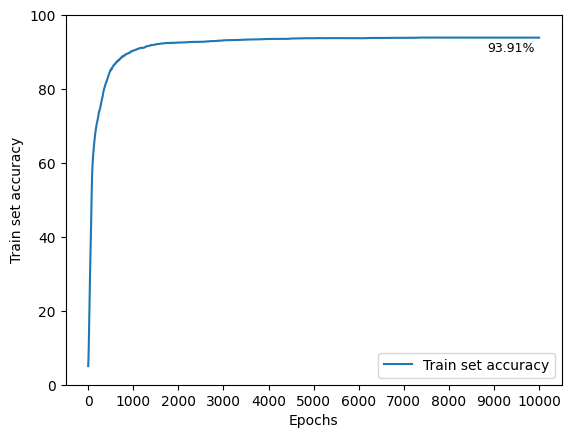

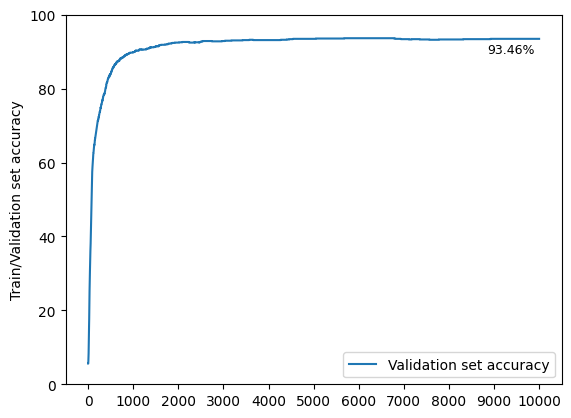

In [ ]:
# plot them, but in a different cell so you dont have to re-train the network each time

# train set accuracy
plt.plot(train*100, label="Train set accuracy")
plt.ylabel("Train set accuracy")
plt.xlabel("Epochs")
plt.gca().set_ylim([0, 100])
plt.xticks(np.arange(0, 10_001, 1000))

plt.annotate(
    f"{train[9_999]*100:.2f}%", 
    xy=(10_000, train[9_999] * 100), 
    xytext=(-20, -10), 
    textcoords="offset points", 
    ha="center", 
    fontsize=9, 
)
plt.legend()
plt.show()

# val set accuracy
plt.plot(val*100, label="Validation set accuracy")
plt.ylabel("Train/Validation set accuracy")
plt.gca().set_ylim([0, 100])
plt.xticks(np.arange(0, 10_001, 1000))

plt.annotate(
    f"{val[9_999]*100:.2f}%",
    xy=(10_000, val[9_999] * 100),
    xytext=(-20, -10),
    textcoords="offset points",
    ha="center",
    fontsize=9,
)

plt.legend()
plt.show()

In [ ]:
# time the difference between running the validation set between
# a network with 20 hidden layer nodes and 30 hidden layer nodes

import time
# time.time() returns seconds since epoch (1 january 1970)
iters = 50_000
time_20s = np.zeros(iters)
time_30s = np.zeros(iters)
for i in range(iters):
    # network is Network([Linear(10, 20), Linear(20, 20), Linear(20, 7)]) from the original training
    time_20_start = time.time()
    run_network(network, val_features)
    time_20_end = time.time()
    time_20s[i] = time_20_end - time_20_start

    # netw is Network([Linear(10, 30), Linear(30, 30), Linear(30, 7)]) from the training with plots
    time_30_start = time.time()
    run_network(netw, val_features)
    time_30_end = time.time()
    time_30s[i] = time_30_end - time_30_start

decimals = 10
time_20 = np.mean(time_20s)
time_30 = np.mean(time_30s)
print(
    f"Network with 20 neurons per hidden layer took on average {time_20:.{decimals}f} seconds."
)
print(
    f"Network with 30 neurons per hidden layer took on average {time_30:.{decimals}f} seconds."
)
print(f"30 neurons is on average {time_30/time_20} times slower.")

Network with 20 neurons per hidden layer took on average 0.0002997809 seconds.
Network with 30 neurons per hidden layer took on average 0.0004117008 seconds.
30 neurons is on average 1.3733390360200732 times slower.


<div style="background-color:#f1be3e">

Because we only use 2 hidden layers, having a high amount of neurons probably won't make the model take that much longer when running it, so let's test that. After testing, using 30 neurons is about 37.3% slower than 20 neurons. This is completely acceptable because it still finishes in less than 1 millisecond, so the slightly longer runtime is worth the (very) small performance increase.

</div>

### 1.5 Evaluation

#### Question 13

In [ ]:
val_preds = run_network(netw, val_features)
val_acc =   calculate_success_rate(val_preds, val_targets)

test_preds = run_network(netw, test_features)
test_acc =   calculate_success_rate(test_preds, test_targets)

print(f"The success rate on the validation set is {val_acc*100:.2f}%")
print(f"The success rate on the test set is {test_acc*100:.2f}%")

The success rate on the validation set is 93.46%
The success rate on the test set is 92.62%


<div style="background-color:#f1be3e">

The success rate on the test set is a bit lower than on the validation set, which is expected. This is probably because we tuned the amount of neurons per hidden layer to maximize the success rate on the validation set, while we didn't do anything specifically for the test set.

</div>

#### Question 14

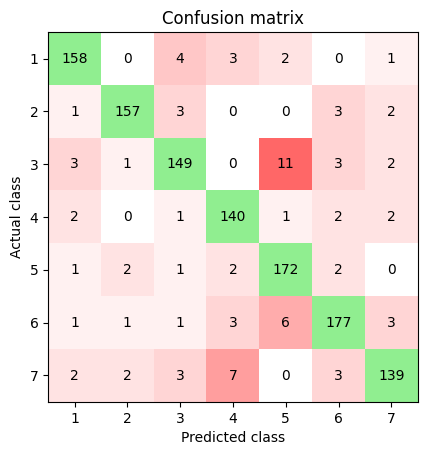

In [ ]:
conf_mat = np.zeros(shape=(7, 7)) # there are 7 classes so 7x7

# subtract 1 from the targets and predictions
# those are 1-indexed and numpy uses 0-indexed arrays
val_preds = run_network(netw, test_features)
np.add.at(conf_mat, (test_targets - 1, val_preds - 1), 1)

# plot the matrix
fig, ax = plt.subplots()

wrong_prediction_cmap = mpl_colors.LinearSegmentedColormap.from_list(
    "wrong", ["#FFFFFF", "#FF6767"]
    #"wrong", ["#FEBAE7", "#FF6966"]
)
right_prediction_cmap = mpl_colors.LinearSegmentedColormap.from_list(
    "right", ["#90EE90", "#90EE90"]
)

# np.ma.masked_where keeps values where the mask is false
# np.eye(7, dtype=bool) returns a matrix of True but the diagonal is False
wrong_predictions = np.ma.masked_where(np.eye(7, dtype=bool), conf_mat)
ax.imshow(wrong_predictions, cmap=wrong_prediction_cmap)

right_predictions = np.ma.masked_where(~np.eye(7, dtype=bool), conf_mat)
ax.imshow(right_predictions, cmap=right_prediction_cmap)

for i in range(7):
    for j in range(7):
        ax.text(j, i, int(conf_mat[i, j]), ha="center", va="center", color="black")

ax.set_xticks(range(7), labels=range(1, 8))
ax.set_xlabel("Predicted class")
ax.set_yticks(range(7), labels=range(1, 8))
ax.set_ylabel("Actual class")
ax.set_title("Confusion matrix")

plt.show()

<div style="background-color:#f1be3e">

The confusion matrix is a matrix that shows how much a model confuses a pair of classes. You can see that our model struggles differentiating class 3 from class 5, with 11 mistakes. It also confuses class 7 with class 4 and class 6 with class 5. Most of the predictions are on the diagonal though, which is the goal.
</div>

#### Question 15

In [ ]:
with open("35_classes.txt", "w") as f:
    unknown_predictions = run_network(netw, unknown)
    f.write(",".join(unknown_predictions.astype(str)))

<div style="background-color:#f1be3e">

As of right now, the autograder is bugged and does not work.

</div>

### 1.6 Scikit-learn

#### Question 16

### output

<div style="background-color:#00000">


Grid search on grid:

-hidden_layer_sizes: [[8, 8], [8, 8, 8], [8, 8, 8, 8], [15, 15], [15, 15, 15], [20, 20], [20, 20, 20]]

-activation: ['logistic', 'identity', 'logistic', 'tanh', 'relu']

-alpha: [0, 0.01, 0.001, 0.005]

-solver: ['adam']

-learning_rate_init: [0.005, 0.01]

-max_iter: [10000]

-batch_size: ['auto']

-validation_fraction: [0.12749999999999997]

-early_stopping: [True]

-n_iter_no_change: [10]

-tol: [0.0001]

-random_state: [42]

Fitting 5 folds for each of 280 candidates, totalling 1400 fits
Best parameters found by grid search:

-activation: identity

-alpha: 0

-batch_size: auto

-early_stopping: True

-hidden_layer_sizes: [8, 8]

-learning_rate_init: 0.005

-max_iter: 10000

-n_iter_no_change: 10

-random_state: 42

-solver: adam

-tol: 0.0001

-validation_fraction: 0.12749999999999997

Scikit evaluation output

Resulting Training Cross-Entropy loss: 0.18775284403710557

Resulting Test Cross-Entropy loss: 0.18902778693879665


Resulting Training accuracy: 0.9307865168539325

Resulting Validation accuracy: 0.9166666666666666

Resulting Test accuracy: 0.9304495335029687


Resulting Training MSE: 0.015000617940546862

Resulting Test MSE: 0.0140484606835606

### answer
<div>

So the modal chose 2 hidden layers of size 8, with activation function Identity. 

While we chose for 2 layers of size 20, and ReLU activation.

In training performance we can already see that Scikit is way more efficient then our solution. What took >45 minutes to train with our code took Scikit about 2 minutes to "learn" the optimal network of the options provided.

Seemingly on the data there is no massive increase when picking more nodes per layer then the 8. 
This is supported by the results, our modal got 93.55% accuracy on the traing data and 92.45% on the test data. While this (smaller) model gets 93% on the training and 93% on the test data. So it is slightly worse for the training data, yet slightly better on unseen data.
</div>

#### Question 17

In [ ]:
class ActivationS:
    def __init__(self):
        self.cache = None
    
    def forwardS(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        self.cache = x
        return x
    
    def backwardS(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        return dupstream

class NetworkS:
    def __init__(self, layers):
        self.layers = layers
        self.activations = [ActivationS() for _ in range (len(layers) - 1)]
        
    def forward(self, x):
        """ Perform a forward pass over the entire network.
        
        Args:
            x: input data.

        Returns:
            y: predictions.
        """
        
        for i in range(len(self.layers) - 1):
            layer = self.layers[i]
            x = self.activations[i].forwardS(layer.forward(x))

        x = self.layers[-1].forward(x)
        x_stable = x - np.max(x, axis=0, keepdims=True)
        return np.exp(x_stable) / np.sum(np.exp(x_stable), axis = 0, keepdims = True) 
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        dupstream = self.layers[-1].backward(dupstream)
        for i in range(len(self.layers) - 2, -1, -1):
            dupstream = self.layers[i].backward(self.activations[i].backwardS(dupstream))
        return dupstream

    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        for layer in self.layers:
            layer.weight -= layer.weight_grad * lr
            layer.bias   -= layer.bias_grad * lr

0.18270639809925934
0.9361469892668728
The accuracy on the validation set is 93.63%
The accuracy on the test set is 92.62%


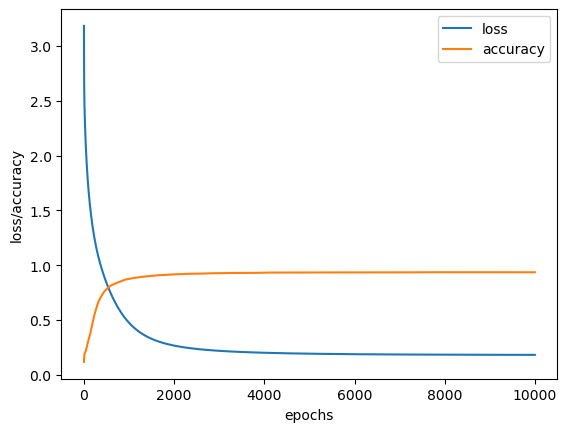

In [ ]:
network = NetworkS([Linear(10, 8), Linear(8, 8), Linear(8, 7)])
losses, accuracies = train(network, train_features.T, train_targets, Loss, 0.01)

print(losses[-1])
print(accuracies[-1])

plt.plot(losses, label = "loss")
plt.plot(accuracies, label="accuracy")
plt.ylabel("loss/accuracy")
plt.xlabel("epochs")
plt.legend()
plt.show

val_preds = run_network(network, val_features)
val_acc =   calculate_success_rate(val_preds, val_targets)

test_preds = run_network(network, test_features)
test_acc =   calculate_success_rate(test_preds, test_targets)

print(f"The accuracy on the validation set is {val_acc*100:.2f}%")
print(f"The accuracy on the test set is {test_acc*100:.2f}%")

<div style="background-color:#00000">
    So by doing a small modification to the classes for accomodating the new activation function we see a training accuracy of 93.72%, validation accuracy of 93.46% and a test accuracy of 92.96%</BR>
    These values are a small bit away from our orignals results, getting at most 0.5% extra, this being on the test accuracy. 
    So the decrease in neurons did improve the network, showing that we had a bit too much overfitting with 20 neurons per layer. 
</div>

### 1.7 Reflection

#### Question 18

<div>

In banking classifications are used to see if individuals are able to repay loans. 

If in these systems there is a bias towards allowing the majority race to get a loan more easily, then it would make it more difficult for a minority race to get the same loan.

It could become so bad, that even if you have two almost similar individuals, where they only differ in one place: race, and then one would get accepted, but the other not. Simply because of the bias. 

This in turn is quite harmful, as this means that the banking discriminates against the minority race. So these people will not get the same chances someone else would.


</div>

#### Question 19

<div>

I am of the opinion that you cannot get "unbiased" data. As we can infer the "discriminatory" factor from other datapoints. Like race can be determined based on living situation, education, salary, etc. Yet "income" would, in my opinion, be needed for a loan-check.

But we can lower the total discrimination done by undersampeling the majority race, and oversampeling the minority race. This will have the result that we see more "positive" minority results, and fewer "positive" majority results. So the algorithm gets tuned to have the curves almost the same.

Another approach is to give people the ability to re-evalutate the given result by a human. Which can then use a checklist to see if the person should have gotten a loan. With this you can at least ensure that if the system is mistaken the disatvantaged individuals have a way to still get to have the same chances, although it might require some extra time.


But even with these points, my original opinion still stands. The system is still biased. If you have to alter data distributions to get an "acceptable" outcome, then the system is inherently flawed.

The issue with the first approach is that it is still a black box, we don't know for certain if it no longer considers race as a rejection criterea. 
The results might show that the issue seems resolved, but that is on the validation/test data. In reality it might still discriminate in untested cases.

Then the second approach, now we are applying bandaids to a bleeding region in hope of fixing it. We still discriminate against the minority race, but now they can appeal. So besides constantly getting disadvataged by the system, we now also require them to put in effort. Which takes up resources and time, all because of a flawed system.


</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>